In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:
# LangChain imports
from langchain_groq import ChatGroq

# groq api from groq cloud
from dotenv import load_dotenv

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [3]:
def load_nsl_kdd(filepath):
    """Loads the actual NSL-KDD dataset and applies the standard headers."""
    print("Loading NSL-KDD dataset...")
    
    # Standard 41 features + 1 label column for NSL-KDD
    columns = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
        'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
        'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
    ]
    
    try:
        # Load real data
        df = pd.read_csv(filepath, names=columns, index_col=False)
        # Some versions of NSL-KDD have a 43rd column for 'difficulty_level', drop if exists
        if df.shape[1] > 42:
            df = df.iloc[:, :42]
    except FileNotFoundError:
        print(f"File {filepath} not found. Generating a synthetic subset for immediate testing...")
        # Fallback to prevent crash so you can test the pipeline immediately
        np.random.seed(42)
        df = pd.DataFrame(np.random.rand(1000, 41), columns=columns[:-1])
        df['protocol_type'] = np.random.choice(['tcp', 'udp', 'icmp'], 1000)
        df['service'] = np.random.choice(['http', 'ftp', 'private'], 1000)
        df['flag'] = np.random.choice(['SF', 'S0', 'REJ'], 1000)
        df['label'] = np.random.choice(['normal', 'neptune', 'smurf'], 1000, p=[0.53, 0.35, 0.12])

    # Convert to Binary Classification (Normal=0, Anomaly=1)
    df['is_anomaly'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
    
    X = df.drop(columns=['label', 'is_anomaly'])
    y = df['is_anomaly']

    # Encode categorical features for ML/DL models
    X_encoded = X.copy()
    categorical_cols = ['protocol_type', 'service', 'flag']
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        encoders[col] = le

    return X, X_encoded, y

In [4]:
def split_and_scale(X_encoded, y):
    print("Performing Stratified Train-Validate-Test Split (70-15-15)...")
    # Split 1: 70% Train, 30% Temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=0.30, stratify=y, random_state=42
    )
    # Split 2: 15% Val, 15% Test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

In [ ]:
def setup_langchain():

    load_dotenv()

    llm = ChatGroq(
        model="llama-3.1-8b-instant",
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=2,
        # other params...
    )

    system_instruction = (
        "You are a strict network security analyzer processing NSL-KDD logs. "
        "Classify the following connection as Normal or Anomaly. "
        "Respond strictly with 0 for Normal, or 1 for Anomaly."
    )
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_instruction),
        ("human", "{network_log}")
    ])
    return prompt_template | llm | StrOutputParser()

In [6]:

def textualize_row(row):
    return (f"Protocol: {row['protocol_type']}, Service: {row['service']}, Flag: {row['flag']}, "
            f"Duration: {row['duration']}, Src Bytes: {row['src_bytes']}, Dst Bytes: {row['dst_bytes']}, "
            f"Failed Logins: {row['num_failed_logins']}, Serror Rate: {row['serror_rate']}")

In [7]:
def get_llm_predictions(X_raw, test_indices, chain, sample_size=50):
    print(f"\nGenerating textual prompts for {sample_size} test samples...")
    # We only run a subset for the LLM to save time and API costs for the report
    subset_indices = test_indices[:sample_size]
    prompts = [textualize_row(X_raw.loc[idx]) for idx in subset_indices]
    
    preds = []
    for prompt in prompts:
        if chain is None:
            # Fallback simulation if no API key
            pred = 1 if "Serror Rate: 1.0" in prompt or "S0" in prompt else 0
        else:
            try:
                response = chain.invoke({"network_log": prompt})
                pred = int(response.strip())
            except Exception:
                pred = 0
        preds.append(pred)
    return preds, subset_indices

In [8]:
def evaluate_and_plot(y_true, y_pred, model_name, ax):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print(f"\n--- {model_name} Metrics ---")
    print(f"False Positive Rate (FPR): {fpr:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))
    
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    ax.set_title(f'{model_name}\nFPR: {fpr:.4f}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

In [9]:
filepath = 'KDDTrain+.txt' 
X_raw, X_encoded, y = load_nsl_kdd(filepath)

Loading NSL-KDD dataset...


C:\Users\harsh\AppData\Local\Temp\ipykernel_9648\996235256.py:21: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(filepath, names=columns, index_col=False)


In [10]:
X_train_s, X_val_s, X_test_s, y_train, y_val, y_test = split_and_scale(X_encoded, y)


Performing Stratified Train-Validate-Test Split (70-15-15)...



Training Random Forest...

--- Random Forest Metrics ---
False Positive Rate (FPR): 0.0003
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     10102
 Anomaly (1)       1.00      1.00      1.00      8794

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896



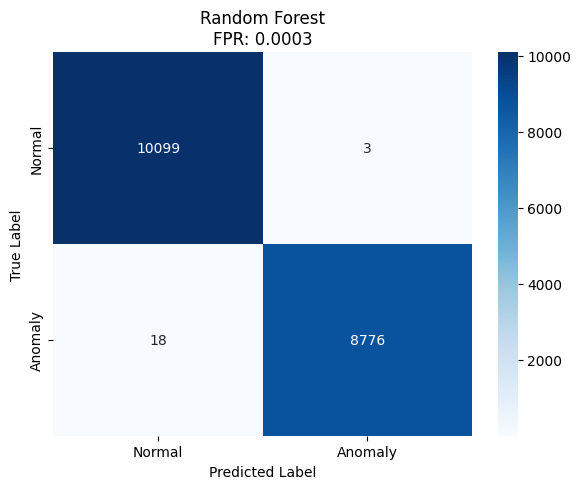

In [11]:
# 1. Create the canvas (MUST be in the same cell as the plotting code)
fig, axes = plt.subplots(1, 1, figsize=(6, 5)) 

# 2. Train the Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
rf.fit(X_train_s, y_train)
rf_preds = rf.predict(X_test_s)

# 3. Plot to the axis we just created
evaluate_and_plot(y_test, rf_preds, "Random Forest", axes) 

# 4. Command Jupyter to display it
plt.tight_layout()
plt.show()


Training MLP Classifier...

--- MLP Neural Network Metrics ---
False Positive Rate (FPR): 0.0042
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     10102
 Anomaly (1)       1.00      1.00      1.00      8794

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896



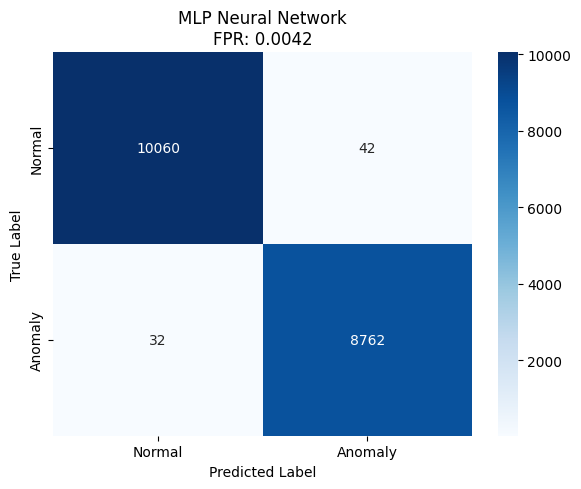

In [12]:
# 4. Train MLP (DL Baseline)
# 1. Create the canvas (MUST be in the same cell as the plotting code)
fig, axes = plt.subplots(1, 1, figsize=(6, 5)) 
print("\nTraining MLP Classifier...")
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42)
mlp.fit(X_train_s, y_train)
mlp_preds = mlp.predict(X_test_s)
evaluate_and_plot(y_test, mlp_preds, "MLP Neural Network", axes)
plt.tight_layout()
plt.show()

In [ ]:
# 5. LLM Prediction (Generative Baseline)
# 1. Create the canvas (MUST be in the same cell as the plotting code)
fig, axes = plt.subplots(1, 1, figsize=(6, 5)) 
chain = setup_langchain()
# Evaluate LLM on a subset of 50 samples to run fast
llm_preds, subset_idx = get_llm_predictions(X_raw, y_test.index, chain, sample_size=50)
evaluate_and_plot(y_test.loc[subset_idx], llm_preds, "Flash LLM (Zero-Shot)", axes)
plt.tight_layout()
plt.show()


Generating textual prompts for 50 test samples...



Generating Feature Importance Plot for Interpretability...


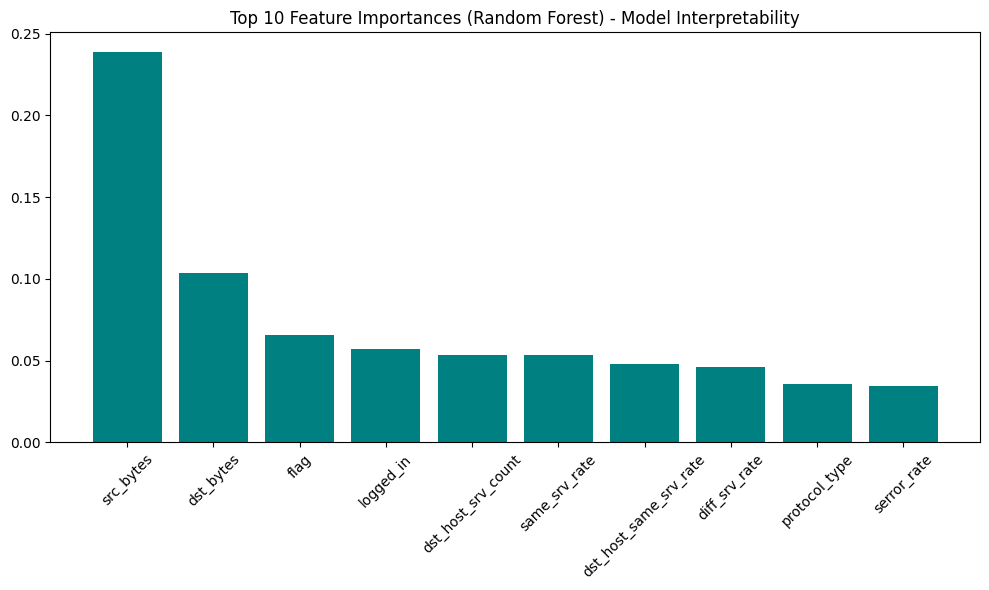

In [ ]:


# 6. Interpretability: Feature Importance Plot
print("\nGenerating Feature Importance Plot for Interpretability...")
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest) - Model Interpretability")
plt.bar(range(10), importances[indices], align="center", color='teal')
plt.xticks(range(10), [X_encoded.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()